# Polynomial Poisson: HO-FNO vs FNO

This notebook creates or loads a polynomial-source Poisson dataset, visualizes it, trains comparable HO-FNO and FNO models, and compares predictions, errors, parameter counts, and runtime. It imports the dataset generator, HO-FNO implementation, spectral convolution, and evaluation metrics from this repository. To replicate the results in the paper, use the hyperparameters detailed in Appendix L.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'polynomial_poisson' else cwd
if not (REPO_ROOT / 'polynomial_poisson').is_dir():
    raise RuntimeError('Run this notebook from the repository root or polynomial_poisson/.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from polynomial_poisson.create_dataset_polynomial_source_poisson_p2 import (
    build_split,
    normalize_targets,
)
from polynomial_poisson.train_and_eval_models import (
    build_model,
    evaluate,
)
from models.FNO import FNO

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Repository:', REPO_ROOT)
print('Device:', device)

Repository: /home/lamsade/acolagrande/ho_fno_arxiv
Device: cuda


## 2. Create or load a dataset

Set `CREATE_FRESH = True` to generate a smaller exploratory dataset. By default, the notebook loads the repository's cached dataset for the selected polynomial degree.

In [ ]:
DEGREE = 5                # Available cached degrees: 1, 2, 3, 5
CREATE_FRESH = False       # True demonstrates dataset creation
RESOLUTION = 64
TRAIN_SAMPLES = 1000        # Used only when CREATE_FRESH=True
TEST_SAMPLES = 200          # Used only when CREATE_FRESH=True

if CREATE_FRESH:
    x_train, y_train = build_split(
        n_samples=TRAIN_SAMPLES, seed=0, degree=DEGREE,
        resolution=RESOLUTION, k_min=8.0, k_max=18.0,
        num_modes=64, spectral_decay=0.75,
    )
    x_test, y_test = build_split(
        n_samples=TEST_SAMPLES, seed=0, degree=DEGREE,
        resolution=RESOLUTION, k_min=8.0, k_max=18.0,
        num_modes=64, spectral_decay=0.75,
    )
    y_train, y_test, target_stats = normalize_targets(y_train, y_test)
    dataset = {
        'x_train': x_train, 'y_train': y_train,
        'x_test': x_test, 'y_test': y_test,
        'metadata': {
            'name': f'polynomial_source_poisson_p{DEGREE}',
            'degree': DEGREE, 'modes': 16,
            'resolution': RESOLUTION, **target_stats,
        },
    }
else:
    dataset_path = (
        REPO_ROOT / 'polynomial_poisson' / 'generated'
        / f'polynomial_source_poisson_p{DEGREE}' / 'dataset.pt'
    )
    dataset = torch.load(dataset_path, map_location='cpu', weights_only=False)

x_train, y_train = dataset['x_train'], dataset['y_train']
x_test, y_test = dataset['x_test'], dataset['y_test']
metadata = dataset['metadata']
print(metadata)
print('train:', tuple(x_train.shape), '->', tuple(y_train.shape))
print('test: ', tuple(x_test.shape), '->', tuple(y_test.shape))

{'name': 'polynomial_source_poisson_p5', 'description': 'Polynomial-Source Poisson dataset. Inputs are p independent band-limited random Fourier fields. The target solves the periodic Poisson equation -Delta v = prod_j u_j - mean(prod_j u_j).', 'resolution': 64, 'train_samples': 1000, 'test_samples': 200, 'input_channels': 5, 'output_channels': 1, 'modes': 16, 'creation_script': 'create_dataset_polynomial_source_poisson_p2.py', 'normalization': {'x_mean': [3.875320619961542e-10, -2.7244095868184104e-10, 3.565219300338818e-11, -1.2558303008614047e-10, -1.0430813157658037e-10], 'x_std': [0.999876856803894, 0.9998767971992493, 0.9998767971992493, 0.9998767971992493, 0.9998767971992493], 'y_mean': -1.9022262931489564e-10, 'y_std': 0.9991573691368103}}
train: (1000, 64, 64, 5) -> (1000, 64, 64, 1)
test:  (200, 64, 64, 5) -> (200, 64, 64, 1)


## 3. Visualize fields and the polynomial source

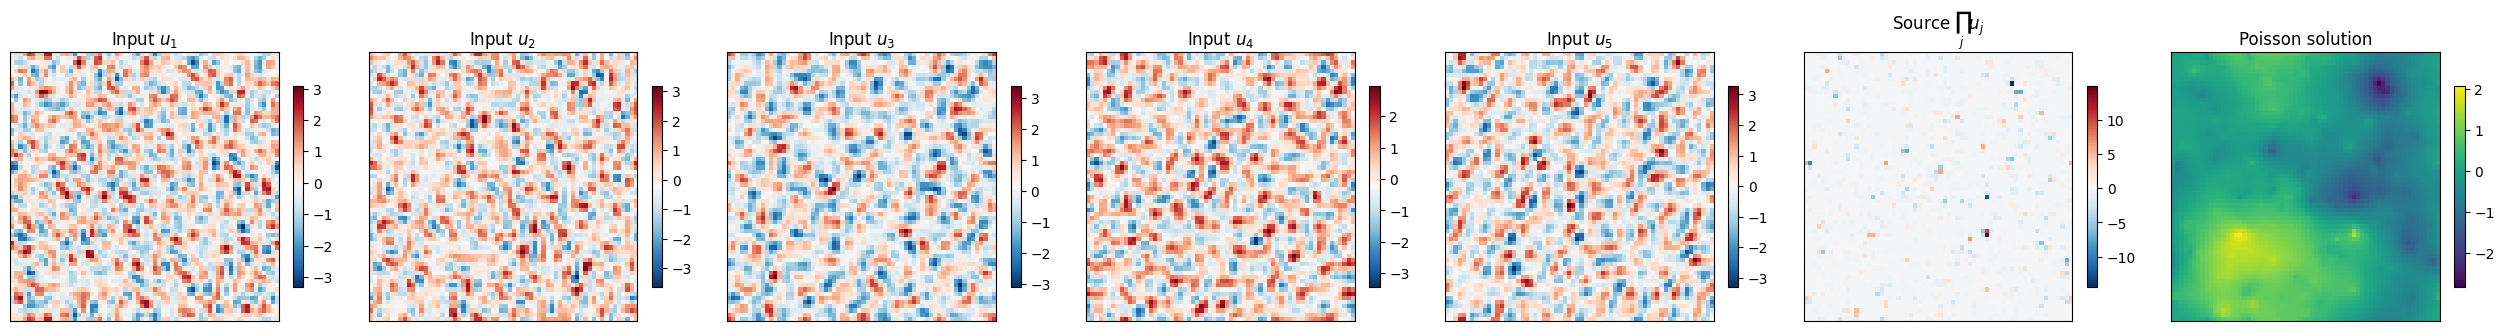

In [3]:
sample_id = 0
inputs = x_train[sample_id]
source = inputs.prod(dim=-1)
target = y_train[sample_id, ..., 0]

ncols = DEGREE + 2
fig, axes = plt.subplots(1, ncols, figsize=(3.6 * ncols, 3.2), constrained_layout=True)
for channel in range(DEGREE):
    image = axes[channel].imshow(inputs[..., channel], cmap='RdBu_r', origin='lower')
    axes[channel].set_title(f'Input $u_{channel + 1}$')
    fig.colorbar(image, ax=axes[channel], shrink=0.75)
image = axes[-2].imshow(source, cmap='RdBu_r', origin='lower')
axes[-2].set_title(r'Source $\prod_j u_j$')
fig.colorbar(image, ax=axes[-2], shrink=0.75)
image = axes[-1].imshow(target, cmap='viridis', origin='lower')
axes[-1].set_title('Poisson solution')
fig.colorbar(image, ax=axes[-1], shrink=0.75)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 4. Models

The FNO baseline in `models/FNO.py` copies the HO-FNO block structure from `HO_FNO.py` and removes only the higher-order product branch. For this demo we compare a 1-layer HO-FNO against a 16-layer FNO.

In [4]:
MODES, ORDER = int(metadata['modes']), DEGREE
HO_FNO_DEPTH = 1
FNO_DEPTH = 16

fno = FNO(
    width=64,
    depth=FNO_DEPTH,
    in_channels=x_train.shape[-1] + 2,
    out_channels=y_train.shape[-1],
    modes1=MODES,
    modes2=MODES,
    p_drop_MLP=0.0,
    drop_path_rate=0.0,
    expansion_MLP=2,
    two_thirds_zero_padding=False,
)

ho_fno = build_model(
    'HO-FNO', x_train.shape[-1], y_train.shape[-1],
    modes=MODES, depth=HO_FNO_DEPTH, order=ORDER,
)

models = {'FNO': fno, 'HO-FNO': ho_fno}
depths = {'FNO': FNO_DEPTH, 'HO-FNO': HO_FNO_DEPTH}
for name, model in models.items():
    print(f'{name:6s}: depth={depths[name]:2d}, {sum(p.numel() for p in model.parameters()):,} parameters')

FNO   : depth=16, 858,689 parameters
HO-FNO: depth= 1, 70,849 parameters


## 5. Train both models

In [5]:
EPOCHS = 20
BATCH_SIZE = 20
LEARNING_RATE = 1e-3

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

def train_model(model, epochs=EPOCHS):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    history = {'train_mse': [], 'test_mse': []}
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        mse_sum = 0.0
        count = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = nn.functional.mse_loss(pred, yb)
            loss.backward()
            optimizer.step()
            batch = xb.shape[0]
            mse_sum += loss.item() * batch
            count += batch
        test = evaluate(model, test_loader, device)
        history['train_mse'].append(mse_sum / count)
        history['test_mse'].append(test['mse'])
        if epoch <= 3 or epoch % 5 == 0 or epoch == epochs:
            print(f'epoch {epoch:03d}/{epochs}: train MSE={mse_sum/count:.5f}, test MSE={test["mse"]:.5f}')
    if device.type == 'cuda':
        torch.cuda.synchronize()
    history['training_seconds'] = time.perf_counter() - started
    return model, history

histories = {}
trained_models = {}
for name, model in models.items():
    print(f'\nTraining {name}')
    torch.manual_seed(SEED)
    trained_models[name], histories[name] = train_model(model)


Training FNO
epoch 001/20: train MSE=1.04706, test MSE=1.01716
epoch 002/20: train MSE=0.99950, test MSE=1.01770
epoch 003/20: train MSE=0.99802, test MSE=1.01570
epoch 005/20: train MSE=0.98779, test MSE=1.02732
epoch 010/20: train MSE=0.17390, test MSE=1.23880
epoch 015/20: train MSE=0.09155, test MSE=1.24901
epoch 020/20: train MSE=0.06274, test MSE=1.25581

Training HO-FNO
epoch 001/20: train MSE=1.00973, test MSE=1.01683
epoch 002/20: train MSE=0.99029, test MSE=0.97576
epoch 003/20: train MSE=0.75420, test MSE=0.51069
epoch 005/20: train MSE=0.37334, test MSE=0.33432
epoch 010/20: train MSE=0.18328, test MSE=0.16683
epoch 015/20: train MSE=0.08739, test MSE=0.08375
epoch 020/20: train MSE=0.04488, test MSE=0.04099


## 6. Learning curves and performance

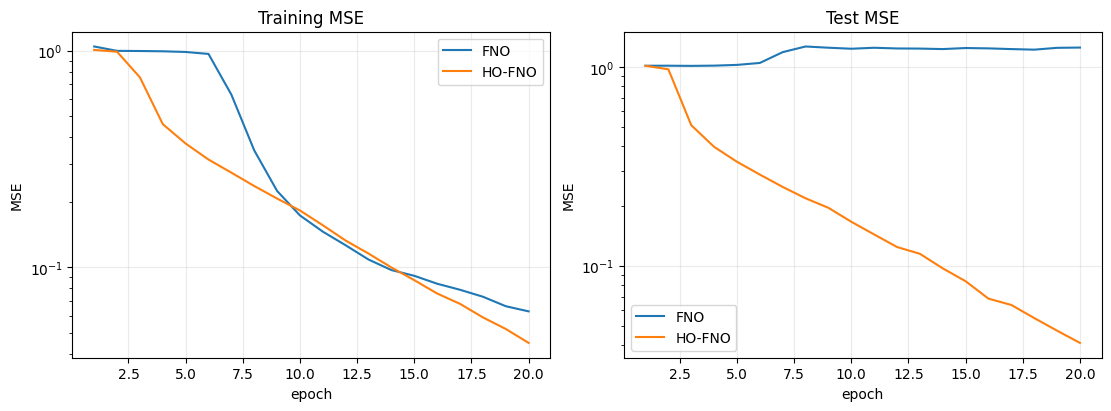

{'FNO': {'parameters': 858689,
  'training_seconds': 72.44394044578075,
  'mse': 1.2558107089996338,
  'rel_l2': 1.1386592626571654},
 'HO-FNO': {'parameters': 70849,
  'training_seconds': 19.49729632725939,
  'mse': 0.04098861664533615,
  'rel_l2': 0.2116708755493164}}

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for name, history in histories.items():
    epochs = np.arange(1, len(history['train_mse']) + 1)
    axes[0].plot(epochs, history['train_mse'], label=name)
    axes[1].plot(epochs, history['test_mse'], label=name)
axes[0].set(title='Training MSE', xlabel='epoch', ylabel='MSE', yscale='log')
axes[1].set(title='Test MSE', xlabel='epoch', ylabel='MSE', yscale='log')
for ax in axes:
    ax.grid(alpha=0.25); ax.legend()
plt.show()

summary = {}
for name, model in trained_models.items():
    metrics = evaluate(model, test_loader, device)
    summary[name] = {
        'parameters': sum(p.numel() for p in model.parameters()),
        'training_seconds': histories[name]['training_seconds'],
        **metrics,
    }
summary

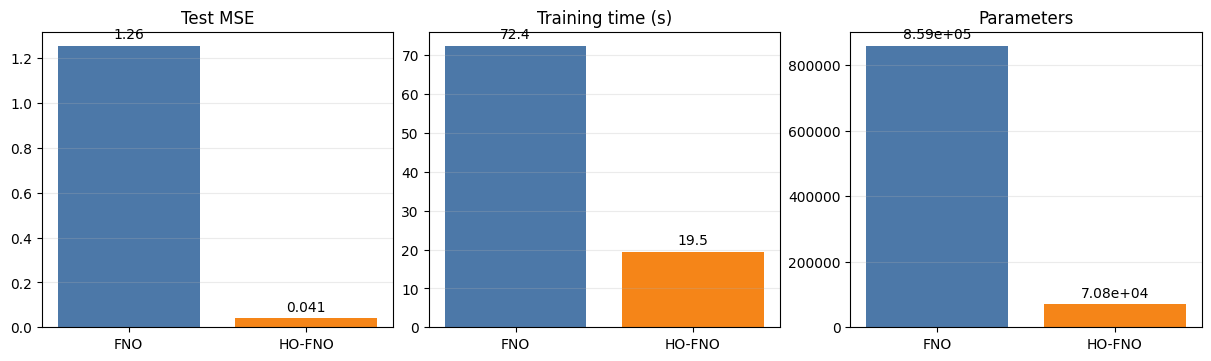

In [8]:
names = list(summary)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
metrics = [('mse', 'Test MSE'), ('training_seconds', 'Training time (s)'), ('parameters', 'Parameters')]
for ax, (key, title) in zip(axes, metrics):
    values = [summary[name][key] for name in names]
    bars = ax.bar(names, values, color=['#4C78A8', '#F58518'])
    ax.set_title(title)
    ax.bar_label(bars, fmt='%.3g', padding=3)
    ax.grid(axis='y', alpha=0.25)
plt.show()

## 7. Prediction and error maps

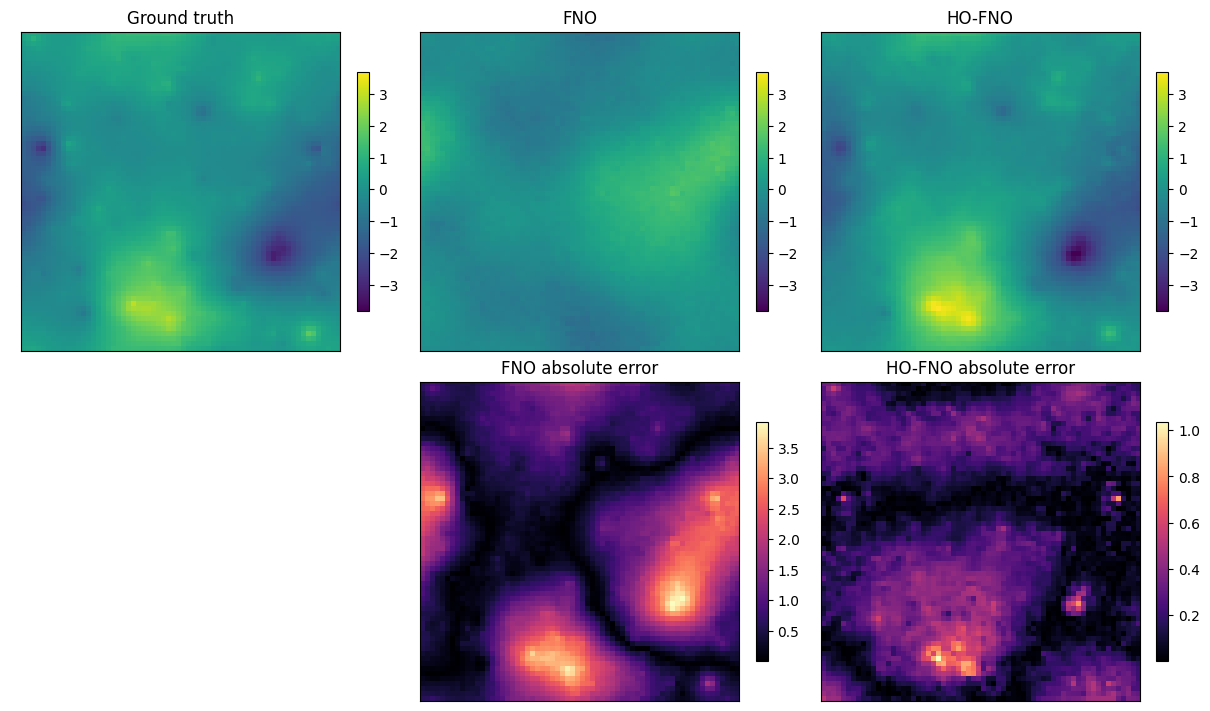

In [9]:
test_id = 0
xb = x_test[test_id:test_id + 1].to(device)
truth = y_test[test_id, ..., 0].cpu()
predictions = {}
for name, model in trained_models.items():
    model.eval()
    with torch.inference_mode():
        predictions[name] = model(xb)[0, ..., 0].cpu()

vmin = min([truth.min().item()] + [p.min().item() for p in predictions.values()])
vmax = max([truth.max().item()] + [p.max().item() for p in predictions.values()])
fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
image = axes[0, 0].imshow(truth, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Ground truth')
fig.colorbar(image, ax=axes[0, 0], shrink=0.75)
axes[1, 0].axis('off')
for col, (name, pred) in enumerate(predictions.items(), start=1):
    image = axes[0, col].imshow(pred, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(name)
    fig.colorbar(image, ax=axes[0, col], shrink=0.75)
    error = (pred - truth).abs()
    image = axes[1, col].imshow(error, cmap='magma', origin='lower')
    axes[1, col].set_title(f'{name} absolute error')
    fig.colorbar(image, ax=axes[1, col], shrink=0.75)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.show()